## 1. An Overview Kernel Gradient Discrepancy (KGD)

KGD provides a scalar diagnostic of how close an empirical particle swarm, $Q_n$, is to a target distribution. It is the RKHS norm of the projected Wasserstein gradient field,
$$KGD_Q= ||b(Q,\cdot)||_{\mathcal{H}_K(Q)},$$
where $b(Q,x_i)$ is the variational gradient field - the net deterministic force vector acting on the particles. In our case this is represented as a combination of our Wasserstein loss gradient, our regularisation pull to the prior, and the addtion of some brownian noise:
$$d\vartheta^{(j)}_t = -\left\{ \lambda_n \nabla_\vartheta \mathcal{L}(Q_t)[\vartheta^{(j)}_t] - \nabla_\vartheta \log \pi(\vartheta^{(j)}_t) \right\} dt + \sqrt{2}dB^{(j)}_t$$

The empirical equivalent is as seen below:
$$\vartheta_{t+1}^{\vartheta (j)} = \vartheta_t^{\vartheta (j)} + \epsilon_t\underbrace{\left(-\lambda_n \, \nabla_{\vartheta}\mathcal{L}(Q_n^{(t)})(\vartheta_t^{(j)}) + \nabla_{\vartheta}\log\pi\big(\vartheta_t^{(j)}\big)\right)}_{b(Q_n^{(t)}, \vartheta^{(j)}_t)}\ + \sqrt{2\epsilon_t}\eta_t^{(j)}$$

Expanding the RKHS norm gives

$$\mathrm{KGD}^2(Q)=\iint b(Q,\vartheta)^T K(\vartheta,\vartheta') b(Q,\vartheta')\, dQ(\vartheta)\, dQ(\vartheta')$$
which, for an empirical particle measure $Q_n=\frac{1}{n}\sum_{i=1}^n \delta_{\vartheta^{(j)}},$ reduces to the computable estimator  
$$\mathrm{KGD}^2(Q_n)=\frac{1}{N_p^2}\sum_{j=1}^{N_p}\sum_{l=1}^{N_p} b(Q_n,\vartheta^{(j)})^{T}K(\vartheta^{(j)},\vartheta^{(l)})b(Q_n,\vartheta^{(l)})$$



## 2. Bridging the Notation

Before we can use KGD as a diagnostic tool, we must align the notation across our 2 pieces of core literature as the PrO posteriors paper (McLatchie et al., 2025) and the KGD paper (Chazal et al., 2026) use slightly different conventions.

| Concept / Variable | KGD Paper (Chazal et al.) | PrO Posteriors Paper (McLatchie et al.) | `pymc-prop` Code Base |
| :--- | :--- | :--- | :--- |
| **Domain Variable** | $x \in \mathbb{R}^d$ | $\vartheta \in \Theta$ | Unconstrained arrays (`value_vars` coordinates via `PointMapper`) |
| **Data Observations** | Unspecified / Implicit | $x_{1:n} = (x_1, \dots, x_n)$ | PyMC observed data array `x_obs` |
| **Particle Count** | $n$ | $N_p$ or $p$ | `particles` shape `(n_particles, d)` |
| **Data Fit Loss** | $L(Q)$ | $\frac{1}{n} \sum_{i=1}^n S(P_Q, x_i)$ | `compile_drift_for_logscore` / `ScoringRule` protocol |
| **Loss Scaling / Temp** | Unscaled ($\lambda = 1$) | Learning rate $\lambda_n$ | `learning_rate` parameter (default `1.0`) |
| **Target Objective** | $J(Q) = L(Q) + D_{\text{KL}}(Q \parallel Q_0)$ | $J(Q) = \lambda_n L(Q) + D_{\text{KL}}(Q \parallel \Pi)$ | Calculated via interacting drift + prior pull |
| **Data Gradient Force** | $\nabla \delta L(Q)[x]$ | $-\lambda_n \nabla_\vartheta \mathcal{L}(Q)[\vartheta^{(j)}]$ | `compiled_drift(particles)` output tensor `(N_p, d)` |
| **Prior Anchor Force** | $\nabla \log q_0(x)$ | $\nabla_\vartheta \log \pi(\vartheta^{(j)})$ | `compile_prior_gradient(model)` |
| **Particle Interactions** | Implicit in variational gradient $b(Q,x)$ | Pairwise mixture weights $w_{i,j}$ / MMD gradients | Evaluated elementwise across observations in unconstrained space |
| **Convergence Metric** | $\mathrm{KGD}^2(Q_n) = \frac{1}{n^2}\sum_{i,j} b_i^T K_{i,j} b_j$ | Monitored via WGF stationarity | This notebook's addition |

## 3. Implementing KGD

The beauty of evaluating KGD within `pymc-prop` is that the most computationally expensive operations, evaluating the log-score gradients across the dataset and the prior, are already handled natively inside the Wasserstein Gradient Flow (WGF) loop.

$b(Q, \vartheta)$ represents the variational gradient (the net deterministic force) which is currently calculated by the `scaled_drift` function, when isolating the variational gradient vector $b(Q, \vartheta)$ from this time_step() update, we must extract only the net deterministic drift, the combination of the prior pull and the data-fit score scaled by $\lambda_n$. We explicitly exclude both the numerical integration step_size and the injected Brownian noise. Excluding step_size ensures KGD remains a continuous-time metric that serves as an absolute, step-size-independent stopping criterion, while omitting Brownian noise prevents stochastic variance from obscuring the smooth convergence of our diagnostic to zero.

With the pure drift tensor (shape `N_p, d`) isolated, computing KGD requires only three steps:
1. Extract the raw `drift` and `particles` tensors at a given time step.
2. Define a positive-definite RKHS kernel to measure the spatial correlation of the particles.
3. Compute the double sum estimator of the kernelized forces efficiently.

In [18]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# Internal building blocks mapping to the pymc_prop structure
from pymc_prop.fuse import FuseState, fuse_step_size
from pymc_prop.particles import initialize_particles, scaled_drift, time_step
from pymc_prop.points import make_point_mapper
from pymc_prop.scoring import LogScore

az.style.use("arviz-variat")

Below is the RBF (Gaussian) Kernel implementation including the Median Heuristic calculation along with the overarching KGD compute function.

In [26]:
def rbf_kernel(particles: np.ndarray, lengthscale: float | None = None) -> np.ndarray:
    """
    RBF Gram matrix $K(\vartheta^{(j)}, \vartheta^{(l)})$.
    
    If lengthscale is None, bandwidth is dynamically estimated using the median 
    heuristic
    """
    diffs = particles[:, None, :] - particles[None, :, :]
    sq_dists = np.sum(diffs ** 2, axis=-1)

    if lengthscale is None:
        n_particles = particles.shape[0]
        off_diag = sq_dists[np.triu_indices(n_particles, k=1)]
        median_sq = np.median(off_diag) if off_diag.size else 0.0
        # guard against a fully-collapsed cloud (median_sq == 0)
        bandwidth = median_sq / np.log(n_particles) if median_sq > 0 else 1.0
        bandwidth = max(bandwidth, 1e-12)
    else:
        bandwidth = max(lengthscale ** 2, 1e-12)

    return np.exp(-sq_dists / bandwidth)


def compute_kgd(particles: np.ndarray, scaled_drift: np.ndarray, lengthscale: float | None = None) -> float:
    """
    Computes KGD^2(Q_n) = (1/N_p^2) sum_j sum_l b_j^T K_jl b_l.
    
    ``forces`` is the pure drift tensor b(Q_n, vartheta) ensuring it is independent of 
    stochastic noise and step size.
    """
    n_particles = particles.shape[0]
    K = rbf_kernel(particles, lengthscale=lengthscale)
    
    # Evaluate the RKHS norm via einsum: sum over particle j, particle l, and dimension d
    quad = np.einsum("jd,jl,ld->", scaled_drift, K, scaled_drift)
    return float(quad / (n_particles ** 2))

This is what it could look like when added to the main sample function (with a lot of generality simplified for the demo).

In [ ]:
def sample_pro_with_kgd(
    model=None,
    n_particles: int = 40,
    n_steps: int = 1000,
    tune: int = 200,
    step_size: float | None = None,
    learning_rate: float = 1.0,
    lengthscale: float | None = None,
    kgd_compute_every: int = 10,
    r_eps: float = 1e-5,
    random_seed: int | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run the log-score PrO sampler while tracking KGD. 
    KGD is computed periodically to save O(N^2) overhead.
    """
    model = pm.modelcontext(model)
    if n_particles < 2:
        raise ValueError("n_particles must be at least 2.")

    mapper = make_point_mapper(model)
    drift_fn = LogScore().compile_drift(model, mapper)

    rng = np.random.default_rng(random_seed)
    particles = initialize_particles(model, mapper, n_particles, rng)

    use_fuse = step_size is None
    fuse_state: FuseState | None = None
    current_step_size = step_size

    particles_history = []
    kgd_history = []
    kgd_steps = []

    for step in range(tune + n_steps):
        wgf_grad, prior_grad = drift_fn(particles)

        if use_fuse:
            current_step_size, fuse_state, _diag = fuse_step_size(
                particles, wgf_grad, prior_grad, learning_rate, fuse_state, r_eps
            )

        if step >= tune:
            # We only track history and compute KGD on intervals to reduce computational overhead
            if (step - tune) % kgd_compute_every == 0:
                kgd_val = compute_kgd(particles, scaled_drift(wgf_grad, prior_grad, learning_rate), lengthscale=lengthscale)
                kgd_history.append(kgd_val)
                kgd_steps.append(step - tune)
                particles_history.append(particles.copy())

        particles = time_step(particles, prior_grad, wgf_grad, current_step_size, learning_rate, rng)

    return (
        np.stack(particles_history, axis=0), 
        np.asarray(kgd_history, dtype=float), 
        np.asarray(kgd_steps, dtype=int)
    )

--- Running KGD Experiment ---
Steps: 1500 | Step Size: FUSE | Lengthscale: Median Heuristic


C:\Users\patri\AppData\Local\Temp\ipykernel_24932\2259654890.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


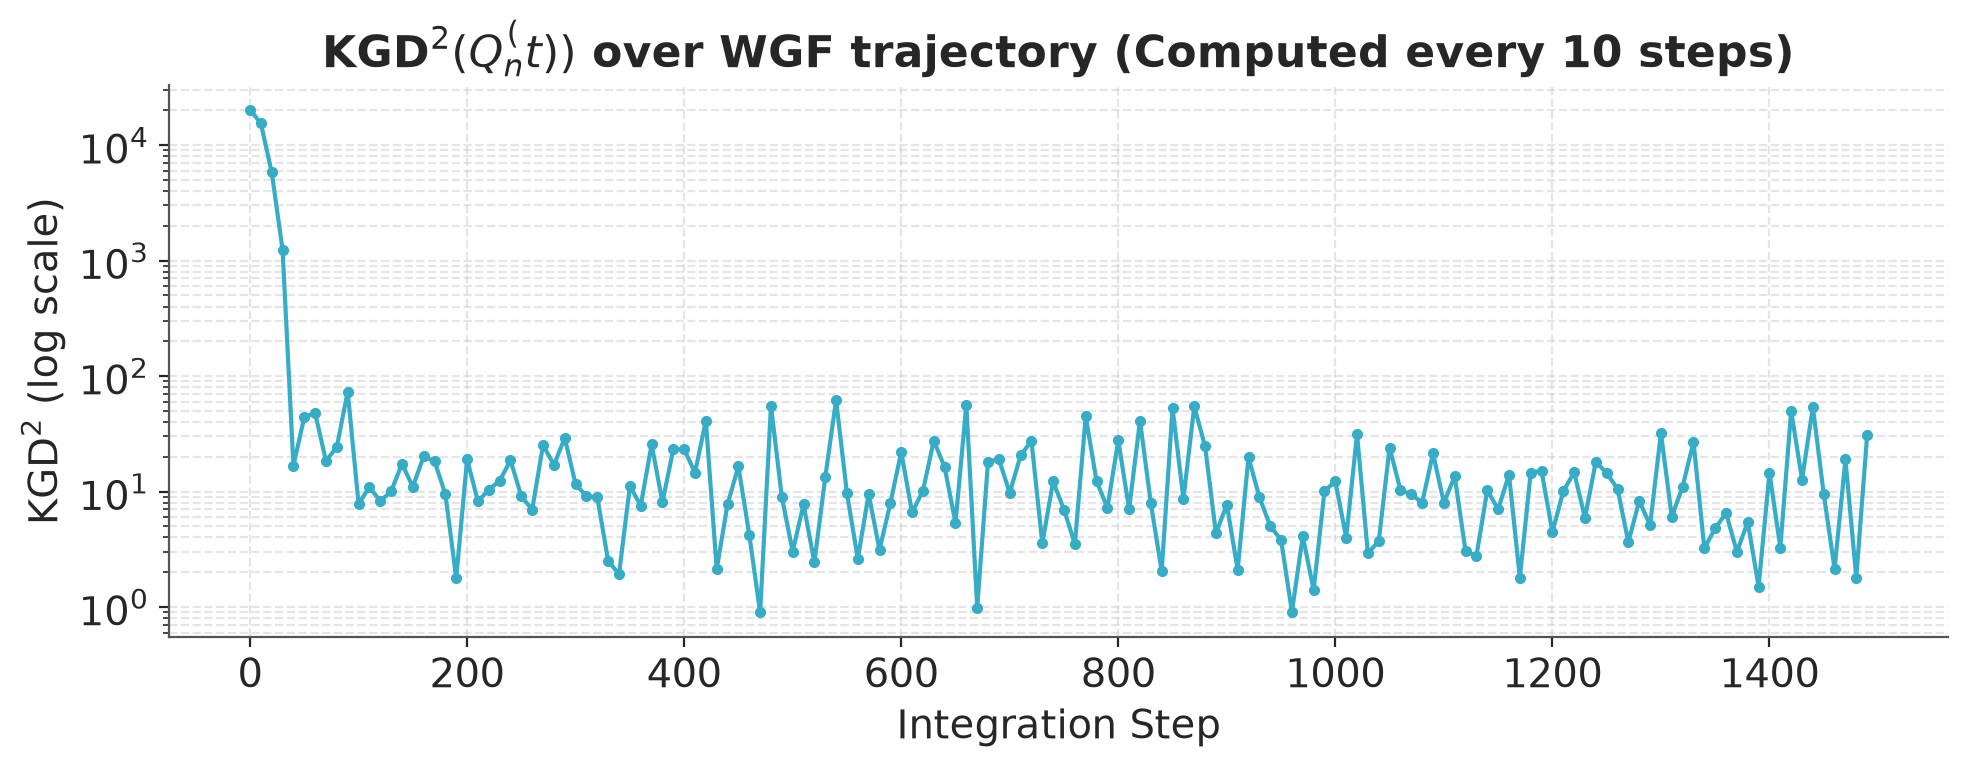

In [28]:
def run_kgd_experiment(
    n_particles=40,
    n_steps=1500,
    step_size=None,
    lengthscale=None,
    kgd_compute_every=10,
    seed=2026
):
    """
    Sets up a 1D Gaussian Mixture Model target and runs the KGD diagnostic suite.
    Allows for testing the impact of fixed step sizes vs. fuse heuristics, and 
    fixed lengthscales vs. the median heuristic.
    """
    print(f"--- Running KGD Experiment ---")
    print(f"Steps: {n_steps} | Step Size: {'FUSE' if step_size is None else step_size} | "
          f"Lengthscale: {'Median Heuristic' if lengthscale is None else lengthscale}")
    
    # 1. Generate Synthetic Data
    N = 300
    sigma = 0.7
    component_means = np.array([-1.5, 2.25])
    component_weights = np.array([0.4, 0.6])
    rng = np.random.default_rng(seed)
    
    components = rng.choice(len(component_means), size=N, p=component_weights)
    y = rng.normal(loc=component_means[components], scale=sigma)

    # 2. Define PyMC Model
    with pm.Model() as model:
        mu = pm.Normal("mu", mu=0.0, sigma=1.0)
        pm.Normal("y", mu=mu, sigma=sigma, observed=y)

        particles_history, kgd_history, kgd_steps = sample_pro_with_kgd(
            model=model,
            n_particles=n_particles,
            n_steps=n_steps,
            step_size=step_size,
            lengthscale=lengthscale,
            kgd_compute_every=kgd_compute_every,
            r_eps=1e-5,
            tune=0,
            random_seed=seed,
        )
        
    # 3. Plotting Diagnostics
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(kgd_steps, kgd_history, color="C0", lw=1.5, marker="o", markersize=3)
    ax.set_yscale("log")
    ax.set(
        title=f"KGD$^2(Q_n^(t))$ over WGF trajectory (Computed every {kgd_compute_every} steps)",
        xlabel="Integration Step",
        ylabel="KGD$^2$ (log scale)",
    )
    ax.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Run Default Test: FUSE step size and Median Heuristic lengthscale
run_kgd_experiment()